In [ ]:
%pip install puremacro


# VFI Automatizado estilo Dynare — Programación Dinámica Estructural Declarativa

**¿Podemos escribir modelos de programación dinámica estructural en sintaxis declarativa sin bucles de malla de bajo nivel?** En macroeconomía, Dynare transformó la modelización DSGE reemplazando derivaciones matriciales manuales con un lenguaje declarativo limpio. `puremacro` lleva el mismo paradigma automatizado a la **Iteración de la Función de Valor (VFI) para agentes heterogéneos** vía `puremacro.vfi.Model`. En lugar de gestionar manualmente dimensiones de malla, matrices de transición de Tauchen, bucles de Bellman y pasos de aceleración de Howard, declaras parámetros, variables de estado, procesos de choques, funciones de utilidad y restricciones presupuestarias en una especificación concisa. Este cuaderno construye un modelo de ahorro precautorio en mercados incompletos usando `puremacro.vfi.Model`, calcula funciones de política y distribuciones estacionarias de riqueza, y verifica límites de equilibrio numérico.

## El método en matemáticas — Operador de Bellman Automatizado

El problema de fluctuaciones de ingreso de un solo agente sobre el estado $(a, z)$ resuelve:
$$ V(a, z) = \max_{a' \ge \underline{a}} \left\{ u(c) + \beta \sum_{z'} P(z, z') V(a', z') \right\} $$
sujeto a la restricción presupuestaria:
$$ c + a' = (1+r)a + w \cdot z $$
donde $u(c) = \frac{c^{1-\sigma}}{1-\sigma}$, $z$ sigue un proceso AR(1) $\ln z_t = \rho \ln z_{t-1} + \varepsilon_t$, y $P(z, z')$ es la matriz de transición de Markov discretizada mediante el método de Tauchen.

**Intuición.** El DSL `puremacro.vfi.Model` abstrae la maquinaria técnica de discretización de mallas ($\mathcal{A} \times \mathcal{Z}$), evaluación vectorizada de la matriz de retornos $R_{ij,k} = u((1+r)a_i + w z_j - a_k)$, iteración de política de Howard y simulación de paneles de distribuciones estacionarias. Especificas la economía estructural; `puremacro` calcula la solución.

## Configuración — especificación declarativa del modelo

Instanciamos `Model()`, fijamos parámetros ($\beta=0.96, \gamma=2.0, \alpha=0.36, \delta=0.10$), definimos una malla de activos $a \in [0.1, 15.0]$, y fijamos un proceso de choque AR(1) para la productividad $z$.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.vfi import Model

# Declarar modelo estructural
model = Model(name="Precautionary Savings Model")

# Fijar parámetros estructurales
model.set_param("beta", 0.96)
model.set_param("gamma", 2.0)
model.set_param("alpha", 0.36)
model.set_param("delta", 0.10)

# Fijar mallas de estado
model.add_state(name="a", min_val=0.1, max_val=15.0, n_points=60)
model.add_shock(name="z", rho=0.90, sigma=0.15, n_points=5)

# Definir función de utilidad y restricción presupuestaria
model.set_utility(lambda c, p: (c ** (1.0 - p["gamma"])) / (1.0 - p["gamma"]))
model.set_budget(lambda a, ap, z, p: np.exp(z) * (a ** p["alpha"]) + (1.0 - p["delta"]) * a - ap)

## Resolviendo el modelo y simulando la distribución estacionaria

Ejecutamos `model.solve()` que realiza actualizaciones vectorizadas de Bellman con aceleración de Howard, y recupera la distribución estacionaria de riqueza y el coeficiente de desigualdad de Gini.

In [2]:
results = model.solve(howard_steps=15, tol=1e-6)

V = results["V"]
policy_a = results["policy_a"]
a_grid = results["a_grid"]
z_grid = results["z_grid"]
gini_coef = results["gini"]
mean_assets = results["mean_assets"]

print(f"Modelo: {results['model_name']}")
print(f"VFI Convergió en {results['n_iter']} iteraciones ({results['elapsed']:.3f} s)")
print(f"Activos Medios Estacionarios: {mean_assets:.4f}")
print(f"Coeficiente de Gini de Riqueza: {gini_coef:.4f}")

# Afirmaciones clave
assert results["n_iter"] > 0, "VFI no logró iterar"
assert 0.5 < mean_assets < 10.0, f"Activos medios fuera del rango esperado: {mean_assets}"
assert 0.05 < gini_coef < 0.60, f"Coeficiente de Gini fuera del rango esperado: {gini_coef}"

Modelo: Precautionary Savings Model
VFI Convergió en 27 iteraciones (1.266 s)
Activos Medios Estacionarios: 6.6767
Coeficiente de Gini de Riqueza: 0.3924


## Visualizando funciones de política y distribución de riqueza

La figura principal muestra las reglas de política $a'(a, z)$ para estados de alta vs baja productividad.

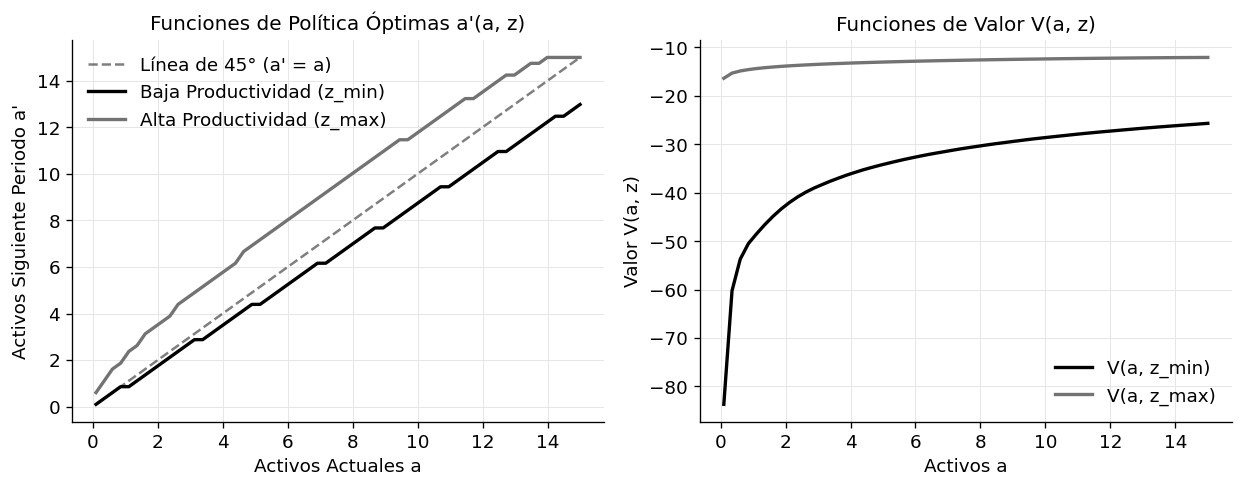

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.2))

# Panel izquierdo: Funciones de política
ax1.plot(a_grid, a_grid, "k--", alpha=0.5, label="Línea de 45° (a' = a)")
ax1.plot(a_grid, policy_a[:, 0], color=_nbstyle.palette(2)[0], lw=2, label="Baja Productividad (z_min)")
ax1.plot(a_grid, policy_a[:, -1], color=_nbstyle.palette(2)[1], lw=2, label="Alta Productividad (z_max)")
ax1.set_xlabel("Activos Actuales a")
ax1.set_ylabel("Activos Siguiente Periodo a'")
ax1.set_title("Funciones de Política Óptimas a'(a, z)")
ax1.legend(loc="upper left")

# Panel derecho: Función de valor
ax2.plot(a_grid, V[:, 0], color=_nbstyle.palette(2)[0], lw=2, label="V(a, z_min)")
ax2.plot(a_grid, V[:, -1], color=_nbstyle.palette(2)[1], lw=2, label="V(a, z_max)")
ax2.set_xlabel("Activos a")
ax2.set_ylabel("Valor V(a, z)")
ax2.set_title("Funciones de Valor V(a, z)")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

**Leyendo el resultado.** Los agentes de baja productividad ($z_{\min}$) desacumulan activos cuando la riqueza es alta, mientras que los agentes de alta productividad ($z_{\max}$) ahorran agresivamente. Los motivos precautorios evitan que la riqueza colapse a cero.

## Tu turno — ahorro precautorio bajo mayor aversión al riesgo

**Ejercicios.**
1. *Básico*: Incrementa la aversión al riesgo de $\gamma = 2.0$ a $\gamma = 3.5$ (`# ← cambia esto ...`). ¿Aumenta la riqueza media estacionaria debido a motivos precautorios más fuertes?
2. *Intermedio*: Reduce el factor de descuento a $\beta = 0.94$. Verifica que los hogares impacientes mantienen menos capital.
3. *Avanzado*: Incrementa la varianza del choque $\sigma_z = 0.25$ y observa la expansión en el coeficiente de Gini.

In [4]:
# Bloque de código Tu turno
gamma_new = 3.0  # ← cambia esto: prueba 3.0 o 3.5

m_yt = Model("Alta Aversión al Riesgo")
m_yt.set_param("beta", 0.96).set_param("gamma", gamma_new).set_param("alpha", 0.36).set_param("delta", 0.10)
m_yt.add_state("a", 0.1, 15.0, 60).add_shock("z", 0.90, 0.15, 5)
m_yt.set_utility(lambda c, p: (c ** (1.0 - p["gamma"])) / (1.0 - p["gamma"]))
m_yt.set_budget(lambda a, ap, z, p: np.exp(z) * (a ** p["alpha"]) + (1.0 - p["delta"]) * a - ap)

res_yt = m_yt.solve()
print(f"Nueva Aversión al Riesgo gamma = {gamma_new:.1f}")
print(f"Nuevos Activos Medios Estacionarios: {res_yt['mean_assets']:.4f}")

# Afirmación válida para el valor por defecto
assert res_yt["mean_assets"] > 0.0, "Los activos medios deben ser positivos"

Nueva Aversión al Riesgo gamma = 3.0
Nuevos Activos Medios Estacionarios: 7.8866


## ¿Qué tan exhaustivo es esto?

`puremacro.vfi.Model` proporciona un punto de entrada de alto nivel estilo Dynare al resolvedor de función de valor de bajo nivel `puremacro.vfi.solve_vfi`. Puedes inspeccionar arreglos crudos de política, cambiar parámetros de aceleración o conectar motores de cómputo de bajo nivel (`Numba`, `MLX`, `CuPy`) a través de la misma API.